# LOAD LIBRARIES

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from scipy.stats import randint, uniform
from sklearn.model_selection import  PredefinedSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    infer_cv_block_size_from_gaps,
    create_block_splits,
    plot_cv_splits
)

# CONFIGURATION

In [13]:
START_DATE, END_DATE = '2023-10-18', '2024-08-22'
TARGET_FLUX = 'FN2O'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = True # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = True
UNDERSAMPLE = False
ADD_ID = True
ADD_TRT = True

# LOAD DATA

In [14]:
data_main = fluxes = load_parquet(filepath=r"82.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 82.1.1_GapFillingDataset.parquet (0.254 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Using data from 2023-10-18 to 2024-08-22

Target column: FN2O_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_50_QCF_gfXGBoost,NEE_L3.3_CUT_50_QCF0_gfXGBoost,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0,FN2O_L3.3_CUT_16_QCF,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_84_QCF,FN2O_L3.3_CUT_16_QCF0,FN2O_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-18 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24
2023-10-18 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25
2023-10-18 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26
2023-10-18 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27
2023-10-18 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,NaN,NaN,4.785047,4.785047,4.861709,0.076663,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.456268,-0.031887,-0.371716,-0.464268,184.456349,187.286349,174.585550,12.443672,188.0,1.0,30.0,1.0,0.0,0.0,14899
2024-08-22 22:15:00,NaN,NaN,4.913285,4.913285,4.809273,-0.104013,2.623038,2.623038,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.399429,-0.000719,-0.361714,-0.454507,184.269841,187.279204,173.906660,14.317380,188.0,1.0,30.0,1.0,0.0,0.0,14900
2024-08-22 22:45:00,NaN,NaN,4.913285,4.913285,4.806984,-0.106301,1.743544,1.743544,1.743544,NaN,NaN,NaN,B,certain,1.0,...,-1.435013,0.009201,-0.350463,-0.453738,184.083333,187.271988,173.230410,16.309472,188.0,1.0,30.0,1.0,0.0,0.0,14901


# CLEAN DATA

In [15]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

data

Filtered parcel_certainty=='certain': 4889/5539 rows kept


,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_50_QCF_gfXGBoost,NEE_L3.3_CUT_50_QCF0_gfXGBoost,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0,FN2O_L3.3_CUT_16_QCF,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_84_QCF,FN2O_L3.3_CUT_16_QCF0,FN2O_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 16:15:00,NaN,NaN,NaN,NaN,1.638105,0.935265,0.324973,0.324973,0.324973,0.324973,0.324973,0.324973,B,certain,1.0,...,-0.444220,0.167777,0.543725,0.460355,0.000000,0.000000,2.274546,1.037818,29.0,22.0,30.0,22.0,0.300629,5.003909,1016
2023-11-07 17:15:00,NaN,NaN,NaN,NaN,1.613576,0.130147,0.339963,0.339963,0.339963,0.339963,0.339963,0.339963,B,certain,1.0,...,-0.431704,0.616304,0.924230,0.889783,0.000000,0.000000,2.263177,1.031258,29.0,22.0,30.0,22.0,0.300637,5.003963,1018
2023-11-07 17:45:00,NaN,NaN,NaN,NaN,1.614751,0.131321,-0.983566,-0.983566,-0.983566,-0.983566,-0.983566,-0.983566,B,certain,1.0,...,-0.346287,1.127378,1.389628,1.462444,0.000000,0.000000,2.257514,1.027996,29.0,22.0,30.0,22.0,0.300642,5.003990,1019
2023-11-07 18:15:00,NaN,NaN,NaN,NaN,1.605338,0.101225,-0.064456,-0.064456,-0.064456,-0.064456,-0.064456,-0.064456,B,certain,1.0,...,-0.150212,1.555405,1.858603,1.930903,0.000000,0.000000,2.251865,1.024747,29.0,22.0,30.0,22.0,0.300646,5.004017,1020
2023-11-07 18:45:00,NaN,NaN,NaN,NaN,1.599435,0.082378,0.066895,0.066895,0.066895,0.066895,0.066895,0.066895,B,certain,1.0,...,-0.287557,2.341769,2.559854,2.970138,0.000000,0.000000,2.246230,1.021509,29.0,22.0,30.0,22.0,0.300651,5.004044,1021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 14:45:00,7.660107,7.660107,7.660107,7.660107,5.347785,-2.312322,0.562096,0.562096,0.562096,0.562096,0.562096,0.562096,A,certain,0.0,...,-1.428149,-0.217355,-0.290252,-0.397630,187.067460,187.379274,184.373050,0.120233,188.0,1.0,30.0,1.0,0.000000,0.000000,14885
2024-08-22 15:15:00,12.252563,12.252563,12.252563,12.252563,5.431583,-6.820980,1.825937,1.825937,1.825937,1.825937,1.825937,1.825937,B,certain,1.0,...,-1.494919,-0.272192,-0.318445,-0.411587,186.880952,187.373056,183.656100,0.247123,188.0,1.0,30.0,1.0,0.000000,0.000000,14886
2024-08-22 15:45:00,8.197114,8.197114,8.197114,8.197114,5.449097,-2.748017,1.238879,1.238879,1.238879,1.238879,1.238879,1.238879,B,certain,1.0,...,-1.467906,-0.339830,-0.338404,-0.407802,186.694444,187.366777,182.941939,0.447626,188.0,1.0,30.0,1.0,0.000000,0.000000,14887


# SELECT FEATURES

In [16]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
# 'timesince_soil_preparation',
# 'n_decay_timed',
# 'timesince_fert',
# 'wfps_0.05_gfXG_lag9h',
# 'wfps_0.05_gfXG_roll3hmean',
# 'ts_0.3_gfXG_lag6h_roll9hmean',
# 'GPP_U50_f_reddyproc_roll3hsum'
# ]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')

# Drop NAs and keep only selected features
train_mask = data[TARGET].notna() & data[selected_features].notna().all(axis=1)
df_train = data.loc[train_mask, selected_features + [TARGET]].copy()
print(f"\nTraining rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[selected_features]
y = df_train[TARGET].astype(float)

df_train


The treatment variable (trt) is included in the feature set

Training rows (complete-case): 4889/4889


,GPP_NT_CUT_50_gfXG_QCF0,ta,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,crop,timesince_soil_preparation,timesince_harvest,timesince_sowing,ts_0.3_gfXG_lag6h,RECO_NT_CUT_50_gfXG_QCF0_roll3hmean,RECO_NT_CUT_50_gfXG_QCF0_roll9hmean,GPP_NT_CUT_50_gfXG_QCF0_roll6hsum,prec_roll3hsum,ts_0.15_gfXG_roll9hmean,...,wfps_0.15_gfXG_lag3h_roll6hmean,wfps_0.3_gfXG_lag6h_roll3hmean,wfps_0.3_gfXG_lag9h_roll9hmean,ts_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,id,trt,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 16:15:00,0.935265,7.300000,11.314175,45.215566,55.151191,1.0,21,60,21,11.299348,1.677709,1.690907,63.537492,0.0,10.947771,...,55.284868,42.926883,42.457769,1.178530,0.652288,-0.465204,0.460355,0.000000,0.000000,2.274546,1.037818,29.0,1016,1.0,0.324973
2023-11-07 17:15:00,0.130147,6.600000,11.401140,45.038043,55.150493,1.0,21,60,21,11.279770,1.645514,1.689157,48.429520,0.7,11.011128,...,55.284022,42.906414,42.510306,-0.260609,0.311134,-0.221122,0.889783,0.000000,0.000000,2.263177,1.031258,29.0,1018,1.0,0.339963
2023-11-07 17:45:00,0.131321,6.633333,11.384078,45.130002,55.166621,1.0,21,60,21,11.223306,1.633395,1.686385,42.764295,0.9,11.046024,...,55.278137,42.875455,42.547311,-1.272530,0.485872,-0.325462,1.462444,0.000000,0.000000,2.257514,1.027996,29.0,1019,1.0,-0.983566
2023-11-07 18:15:00,0.101225,6.366667,11.183588,47.646389,55.322430,1.0,21,60,21,11.287563,1.624275,1.681256,35.064349,1.4,11.100406,...,55.277773,42.857556,42.590066,-0.940764,2.902612,2.423095,1.930903,0.000000,0.000000,2.251865,1.024747,29.0,1020,1.0,-0.064456
2023-11-07 18:45:00,0.082378,6.200000,11.249196,49.572251,55.288503,1.0,21,60,21,11.033730,1.617443,1.676303,27.298352,1.4,11.150393,...,55.264845,42.833137,42.614368,-1.224261,4.965988,4.643261,2.970138,0.000000,0.000000,2.246230,1.021509,29.0,1021,1.0,0.066895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 14:45:00,-2.312322,23.103333,19.119630,26.772063,43.804128,2.0,1,29,60,19.200000,5.275916,4.930448,4.231783,0.0,18.911852,...,44.373130,42.390595,42.491397,6.930371,-1.441244,-3.937213,-0.397630,187.067460,187.379274,184.373050,0.120233,188.0,14885,0.0,0.562096
2024-08-22 15:15:00,-6.820980,24.313333,19.200000,26.544859,43.719702,2.0,1,29,60,19.147037,5.324693,4.989751,-3.979878,0.0,19.013539,...,44.320489,42.391131,42.484240,7.185556,-1.590694,-3.982961,-0.411587,186.880952,187.373056,183.656100,0.247123,188.0,14886,1.0,1.825937
2024-08-22 15:45:00,-2.748017,24.536667,19.238148,26.318742,43.678179,2.0,1,29,60,19.100000,5.359757,5.044722,-7.618098,0.0,19.134095,...,44.269956,42.403261,42.475055,7.205555,-1.752639,-4.001665,-0.407802,186.694444,187.366777,182.941939,0.447626,188.0,14887,1.0,1.238879


# IMBALANCE HANDLING

## UNDER SAMPLING

In [17]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

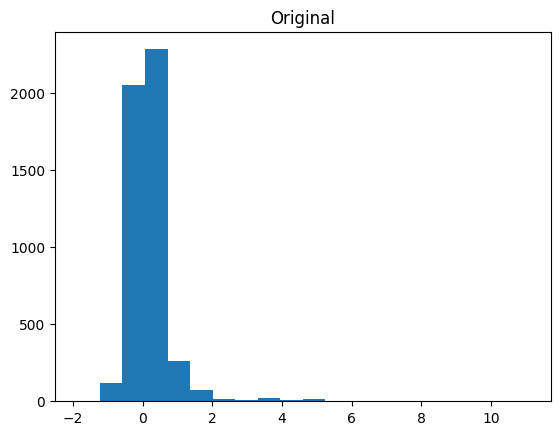

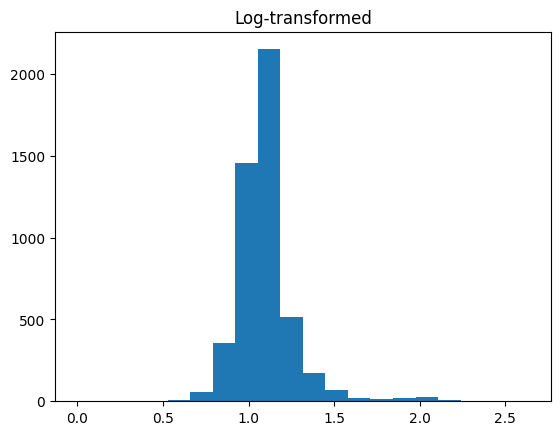

Applied log1p transform (shift=-1.869).


In [18]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")

# CROSS-VAL SPLITS


Using block size of 5 time steps for CV splits.

Requested split=0.10; n_folds=10; achieved test fractions ~ 0.099–0.100


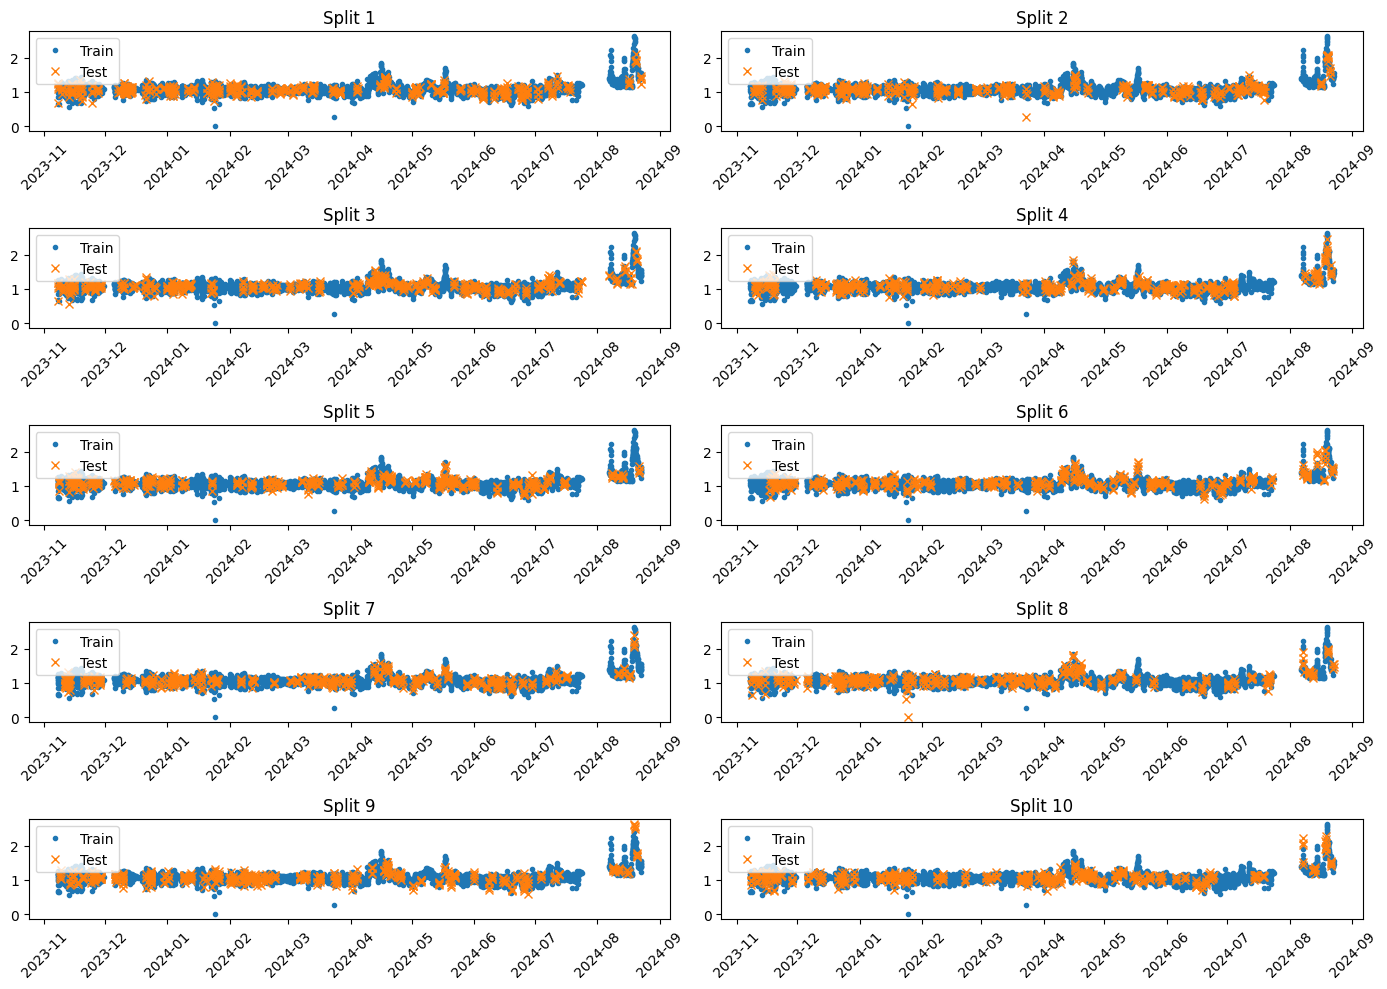

In [19]:
# Time-block cross-validation splits
# Block size is inferred from gaps in the target variable
block_size = infer_cv_block_size_from_gaps(data_main[TARGET], quantile=0.9, fallback=6)
print(f"\nUsing block size of {block_size} time steps for CV splits.\n")
split_frac = 1.0 / float(N_FOLDS)
splits = create_block_splits(
    X,
    split=split_frac,
    block_size=block_size,
    random_state=42,
    shuffle_blocks=True,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# HYPERPARAMETER TUNING

In [20]:
# Convert custom CV splits to PredefinedSplit for Scikit-Learn
test_fold = np.full(len(X), -1)  # Initialize with -1 (all as training)
for fold_idx, (train_idx, test_idx) in enumerate(splits):
    test_fold[test_idx] = fold_idx  # Assign test samples to a specific fold
ps = PredefinedSplit(test_fold)

# DEFINE RANGES
if MODEL_TYPE == 'XGBoost':
    # XGBoost: Use continuous distributions for fine-tuning
    PARAM_DIST = {
        'n_estimators': randint(100, 1000),      # Any integer 100-1000
        'max_depth': randint(3, 15),             # Any integer 3-15
        'learning_rate': uniform(0.005, 0.1),    # Any float 0.005-0.105
        'subsample': uniform(0.6, 0.4),          # 0.6 to 1.0
        'colsample_bytree': uniform(0.6, 0.4),   # 0.6 to 1.0
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 0.5)
    }
    model = XGBRegressor(n_jobs=-1, random_state=42)

elif MODEL_TYPE == 'RandomForest':
    # RF: Integers for counts/depths
    PARAM_DIST = {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 1.0]
    }
    model = RandomForestRegressor(n_jobs=-1, random_state=42)

# RUN RANDOM SEARCH
print(f"Starting optimization for {MODEL_TYPE}...")

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=PARAM_DIST,
    n_iter=100,      # number of random tries
    cv=ps,           # Uses your exact time-blocks
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X, y)

# RESULTS
print(f"Best RMSE: {-search.best_score_:.4f}")
print("Best Params:", search.best_params_)

Starting optimization for XGBoost...
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best RMSE: 0.0932
Best Params: {'colsample_bytree': np.float64(0.6399939548647453), 'gamma': np.float64(0.026742648373684452), 'learning_rate': np.float64(0.10085414968831985), 'max_depth': 5, 'min_child_weight': 9, 'n_estimators': 554, 'subsample': np.float64(0.9827203540505826)}


# EXPORT 

In [21]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(search.best_params_, f)

# **End of notebook**

In [22]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-01-29 11:46:22
